## Conditional Routing with LangGraph - Customer Review Handler

**Problem:** When a company gets a customer review, someone has to read it, figure out if it's positive or negative, and if it's negative, understand *what* went wrong (bug, UX, support issue, etc.) before writing a reply. Doing this manually doesn't scale.

**Use case:** This notebook builds a small LangGraph workflow that automates that process:

1. **`find_sentiment`** — classifies the review as `positive` or `negative` using a structured LLM output.
2. **Conditional edge (`check_sentiment`)** — routes the flow based on the result:
   - If **positive** → straight to `positive_response`, which drafts a warm thank-you message.
   - If **negative** → goes to `run_diagnosis` first, which extracts `issue_type`, `tone`, and `urgency` from the review, then `negative_response` drafts an empathetic reply using that diagnosis.

**What this demonstrates:** structured outputs with Pydantic schemas, a shared `TypedDict` state passed between nodes, and conditional branching in LangGraph based on a node's output.

In [6]:
from langgraph.graph import StateGraph,START,END
from langchain_openai import ChatOpenAI
from typing import TypedDict,Literal
from dotenv import load_dotenv
from pydantic import BaseModel,Field
load_dotenv()
model=ChatOpenAI(model="gpt-4o-mini")

In [21]:
class SentimentSchema(BaseModel):

    sentiment: Literal["positive","negative"]=Field(description="Sentiment of the review")
    

In [8]:
structured_model=model.with_structured_output(SentimentSchema)

In [ ]:
class DiagnosisSchema(BaseModel):
    issue_type: Literal["UX","Performance","Bug","Support","Other"]=Field(description="The category of the issue mentioned in review")
    tone:Literal["angry","frustrated","calm","dissapointed"]=Field(description="The emotions of the user")
    urgency: Literal ["low","medium","high"]=Field(description="How urgent or critial the issue is")


In [24]:
structured_model2=model.with_structured_output(DiagnosisSchema)

In [15]:
# prompt="what is sentiment of this: software is bad"
# structured_model.invoke(prompt).sentiment

In [14]:
class ReviewState(TypedDict):
    review: str
    sentiment: Literal['positive','negative']
    diagnosis: dict 
    response: str

In [16]:
def find_sentiment(state:ReviewState):
    prompt=f"for the following review find out the sentiment\n state['review']"
    sentiment=structured_model.invoke(prompt).sentiment
    return {"sentiment":sentiment}

In [30]:
def check_sentiment(state:ReviewState)->Literal["positive_response","run_diagnosis"]:
    if state["sentiment"].lower()== "positive":
        return 'positive_response'
    else:
        return 'run_diagnosis'
    


def positive_response(state:ReviewState):
    prompt=f"Write a warm thank you message in response to this review \n {state['review']}"
    response=model.invoke(prompt).content
    return {"response":response}


def run_diagnosis(state:ReviewState):
    prompt=f"Diagnose this negative review\n\n {state['review']}\n Return the issue_type,tone and urgency"
    response=structured_model2.invoke(prompt)
    return {"diagnosis":response.model_dump()}


def negative_response(state:ReviewState):
    diagnosis=state['diagnosis']
    prompt=f"You are a support assistant. The user had a {diagnosis['issue_type']} issue, sounded {diagnosis['tone']} and marked urgency {diagnosis['urgency']} Write an empathetic, helpful resolution message"


    response= model.invoke(prompt).content
    return {'response':response}


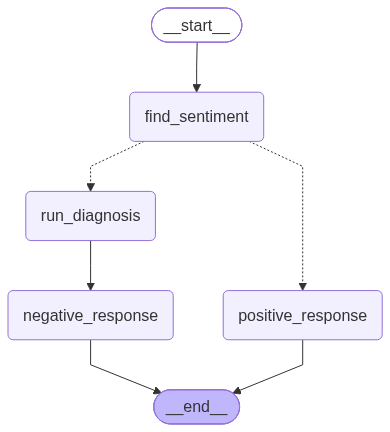

In [31]:
graph=StateGraph(ReviewState)

graph.add_node('find_sentiment',find_sentiment)
graph.add_node('positive_response',positive_response)
graph.add_node('run_diagnosis',run_diagnosis)
graph.add_node('negative_response',negative_response)



graph.add_edge(START,'find_sentiment')
graph.add_conditional_edges('find_sentiment',check_sentiment)
graph.add_edge('positive_response',END)
graph.add_edge('run_diagnosis','negative_response')
graph.add_edge('negative_response',END)

workflow=graph.compile()
workflow



In [33]:
initial_state={
    'review': 'This app is incredible and helps me manage my fleet smoothly, great work by the tech team.'
}

workflow.invoke(initial_state)

{'review': 'This app is incredible and helps me manage my fleet smoothly, great work by the tech team.',
 'sentiment': 'positive',
 'response': "Subject: Thank You for Your Kind Words!\n\nDear [Reviewer's Name],\n\nThank you so much for taking the time to share your positive experience with our app! We’re thrilled to hear that it has been instrumental in helping you manage your fleet smoothly. Your recognition means the world to our tech team, who work tirelessly to ensure our app meets your needs.\n\nIf you have any further feedback or suggestions, please don’t hesitate to reach out. We’re always here to assist you!\n\nWarm regards,  \n[Your Name]  \n[Your Position]  \n[Your Company]  "}